In [62]:
import pandas as pd
# import numpy as n
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
# import seaborn

In [63]:
df = pd.read_csv('../data/sales_sv_2024.csv')

In [64]:
df.head()

,sale_id,date,month,weekday,branch_id,branch_name,department,product_id,product_name,category,unit_price,discount,final_price,quantity,total,payment_method,customer_id
0,1,2024-05-20,5,Monday,1,San Salvador Centro,San Salvador,4,Yuca frita,Traditional Food,2.50,0.0,2.50,8,20.00,Cash,53
1,2,2024-10-29,10,Tuesday,2,Santa Ana,Santa Ana,18,Curtido en frasco,Groceries,2.00,0.0,2.00,14,28.00,Cash,112
2,3,2024-10-14,10,Monday,1,San Salvador Centro,San Salvador,8,Fresco de tamarindo,Beverages,0.75,0.1,0.68,7,4.76,Debit card,280
3,4,2024-08-17,8,Saturday,4,Soyapango,San Salvador,14,Frijoles rojos 1lb,Groceries,1.20,0.0,1.20,19,22.80,Credit card,4
4,5,2024-06-23,6,Sunday,7,La Libertad,La Libertad,6,Kolachampán,Beverages,0.75,0.0,0.75,9,6.75,Cash,391


In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sale_id         2000 non-null   int64  
 1   date            2000 non-null   str    
 2   month           2000 non-null   int64  
 3   weekday         2000 non-null   str    
 4   branch_id       2000 non-null   int64  
 5   branch_name     2000 non-null   str    
 6   department      2000 non-null   str    
 7   product_id      2000 non-null   int64  
 8   product_name    2000 non-null   str    
 9   category        2000 non-null   str    
 10  unit_price      2000 non-null   float64
 11  discount        2000 non-null   float64
 12  final_price     2000 non-null   float64
 13  quantity        2000 non-null   int64  
 14  total           2000 non-null   float64
 15  payment_method  2000 non-null   str    
 16  customer_id     2000 non-null   int64  
dtypes: float64(4), int64(6), str(7)
memory usage

In [66]:
df.describe()

,sale_id,month,branch_id,product_id,unit_price,discount,final_price,quantity,total,customer_id
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,1000.500000,6.648000,4.509500,9.473500,5.245075,0.039850,5.032795,10.45900,51.952910,250.471500
std,577.494589,3.445001,2.300121,5.160873,8.646925,0.055889,8.311940,5.79354,102.849622,144.571767
min,1.000000,1.000000,1.000000,1.000000,0.500000,0.000000,0.420000,1.00000,0.450000,1.000000
25%,500.750000,4.000000,2.000000,5.000000,0.900000,0.000000,0.900000,5.00000,7.050000,123.750000
50%,1000.500000,7.000000,5.000000,10.000000,1.500000,0.000000,1.500000,10.00000,15.000000,252.000000
75%,1500.250000,10.000000,6.000000,14.000000,3.500000,0.100000,3.500000,16.00000,38.855000,375.000000
max,2000.000000,12.000000,8.000000,18.000000,35.000000,0.150000,35.000000,20.00000,700.000000,500.000000


In [67]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

In [68]:
df['date'].dtype

dtype('<M8[us]')

## 📊 Análisis de KPIs principales

In [69]:
# Revenue total - suma de toda la columna total
revenue = df['total'].sum()
print(f'La suma total de las ventas es: {revenue:,.2f}')

La suma total de las ventas es: 103,905.82


In [70]:
# Ticket promedio - promedio de la columna total
total_mean = df['total'].mean()
print(f'El ticket promedio de las ventas es: {total_mean:.2f}')

El ticket promedio de las ventas es: 51.95


In [71]:
# Venta más alta - el valor máximo de total
max_sale = df['total'].max()
print(f'La venta más alta es de: {max_sale:.2f}')

La venta más alta es de: 700.00


## 🏪 Revenue por categoría

In [72]:
revenue_by_category = df.groupby('category')['total'].sum().sort_values(ascending=False)

## 📈 Visualizaciones

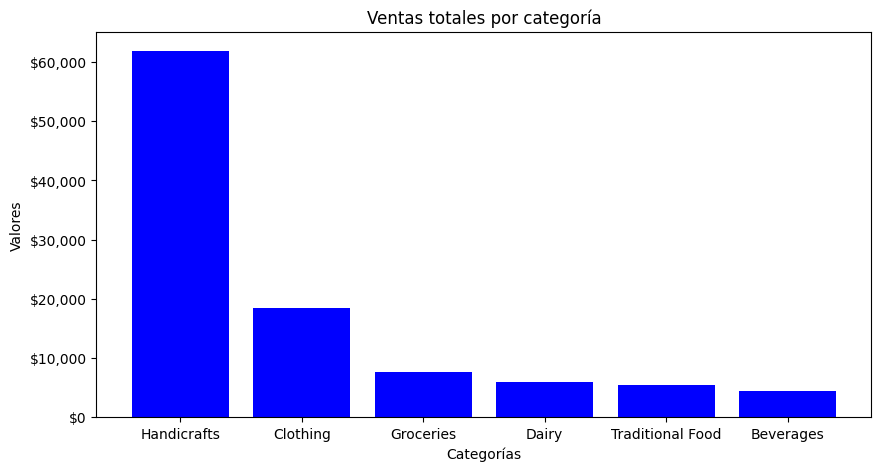

In [73]:
plt.figure(figsize=(10, 5))
plt.bar(revenue_by_category.index, revenue_by_category.values, color='blue')
plt.title('Ventas totales por categoría')
plt.xlabel('Categorías')
plt.ylabel('Valores')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.show()

## 🏪 Revenue por sucursal

In [74]:
revenue_by_branch = df.groupby('branch_name')['total'].sum().sort_values(ascending=False)
revenue_by_branch

branch_name
Chalatenango           16334.34
San Salvador Centro    14121.15
Santa Ana              13615.80
Metrocentro            13151.56
Usulután               12403.31
Soyapango              11993.03
San Miguel             11621.12
La Libertad            10665.51
Name: total, dtype: float64

## 📈 Visualizaciones

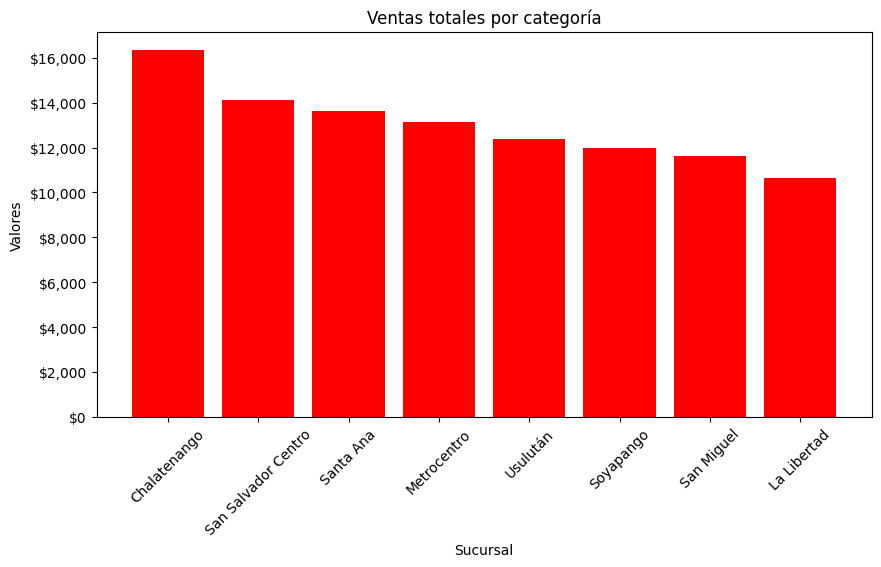

In [75]:
plt.figure(figsize=(10, 5))
plt.bar(revenue_by_branch.index, revenue_by_branch.values, color='red')
plt.xticks(rotation=45)
plt.title('Ventas totales por categoría')
plt.xlabel('Sucursal')
plt.ylabel('Valores')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.show()

## 📅 Tendencia mensual de ventas

In [81]:
monthly_sales_trend = df.groupby(df['date'].dt.to_period('M'))['total'].sum().sort_index()
monthly_sales_trend

date
2024-01     6473.35
2024-02     7927.01
2024-03     9369.71
2024-04     7765.48
2024-05     6390.31
2024-06     8188.16
2024-07     9099.43
2024-08     7500.72
2024-09    10147.85
2024-10     9225.57
2024-11    10053.39
2024-12    11764.84
Freq: M, Name: total, dtype: float64

## 📈 Visualizaciones

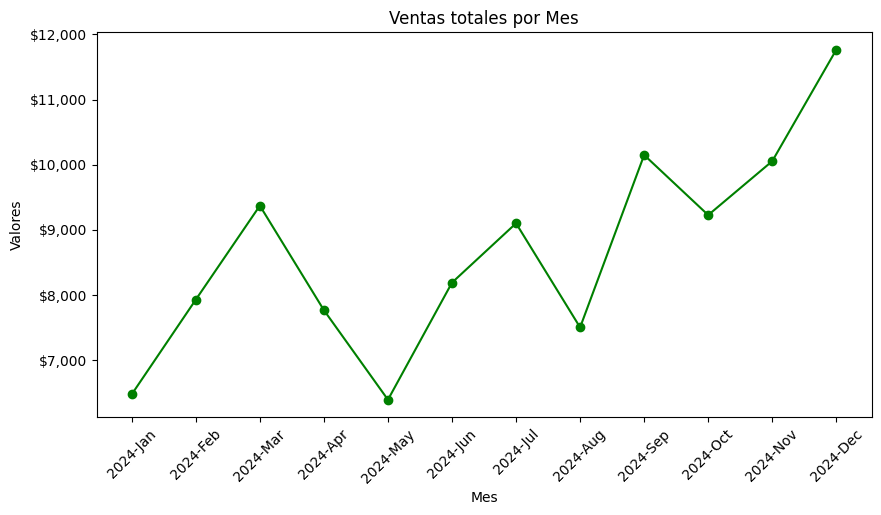

In [82]:
month_names = {
    '01': 'Jan', '02': 'Feb', '03': 'Mar',
    '04': 'Apr', '05': 'May', '06': 'Jun',
    '07': 'Jul', '08': 'Aug', '09': 'Sep',
    '10': 'Oct', '11': 'Nov', '12': 'Dec'
}

labels = [f"{p.split('-')[0]}-{month_names[p.split('-')[1]]}" for p in monthly_sales_trend.index.astype(str)]

plt.figure(figsize=(10, 5))
plt.plot(labels, monthly_sales_trend.values, marker='o', color='green')
plt.xticks(rotation=45)
plt.title('Ventas totales por Mes')
plt.xlabel('Mes')
plt.ylabel('Valores')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.show()

## 📝 Conclusiones

- **Handicrafts** domina el revenue con ~60% del total ($61,934)
- Las **sucursales están balanceadas** — diferencia de solo $5,669 entre la mejor y la peor
- **Tendencia creciente** hacia fin de año — diciembre es el mes pico ($11,764)
- Dataset limpio: 2,000 registros sin valores nulos